# Name: Angel Vasquez, Priyanshu Rathor
# Monday Class: Both Present
# Wednesday Class: Both Present

Dataset:https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
import time

In [71]:
df = pd.read_csv('train.csv')
CLASS_NAMES = ['Low Cost (0)', 'Medium Cost (1)', 'High Cost (2)', 'Very High Cost (3)']
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [72]:
# Drop the target column 'price_range' to get only the input features
X = df.drop(columns=['price_range']).values
# Extract only the target column (what we want to predict)
y = df['price_range'].values

print(f"Feature matrix shape : {X.shape}")
print(f"Label vector shape   : {y.shape}")
print(f"Classes              : {np.unique(y)}  → 0=Low, 1=Medium, 2=High, 3=Very High")

# Scale features (critical for SVM RBF kernel)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature matrix shape : (2000, 20)
Label vector shape   : (2000,)
Classes              : [0 1 2 3]  → 0=Low, 1=Medium, 2=High, 3=Very High


In [73]:
# Split Data and Train
#Split X and y into training (70%) and test (30%) sets
# test_size=0.3 means 30% of data is held back for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [74]:
# TRAIN AND EVALUATE STRATEGY 1 — STANDARD SVM
print("=" * 70)
print("STRATEGY 1: Standard SVM (Default)")
print("=" * 70)

start_time = time.time()
model_standard = SVC(kernel='rbf', gamma='scale', C=1.0)
model_standard.fit(X_train, y_train)
train_time_standard = time.time() - start_time

y_pred_standard = model_standard.predict(X_test)
accuracy_standard = accuracy_score(y_test, y_pred_standard)

print(f"\nResults:")
print(f"  Training time : {train_time_standard:.4f} seconds")
print(f"  Accuracy      : {accuracy_standard * 100:.2f}%")

STRATEGY 1: Standard SVM (Default)

Results:
  Training time : 0.0347 seconds
  Accuracy      : 96.00%


In [75]:
# TRAIN AND EVALUATE STRATEGY 2 — ONE-VS-REST (OvA)
print("=" * 70)
print("STRATEGY 1: Standard SVM (Default)")
print("=" * 70)

start_time = time.time()
model_standard = SVC(kernel='rbf', gamma='scale', C=1.0)
model_standard.fit(X_train, y_train)
train_time_standard = time.time() - start_time

y_pred_standard = model_standard.predict(X_test)
accuracy_standard = accuracy_score(y_test, y_pred_standard)

print(f"\nResults:")
print(f"  Training time : {train_time_standard:.4f} seconds")
print(f"  Accuracy      : {accuracy_standard * 100:.2f}%")

STRATEGY 1: Standard SVM (Default)

Results:
  Training time : 0.0312 seconds
  Accuracy      : 96.00%


In [76]:
# TRAIN AND EVALUATE STRATEGY 3 — ONE-VS-ONE (OvO)
print("=" * 70)
print("STRATEGY 3: One-vs-One (OvO)")
print("=" * 70)

start_time = time.time()
model_ovo = OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
model_ovo.fit(X_train, y_train)
train_time_ovo = time.time() - start_time

y_pred_ovo = model_ovo.predict(X_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

print(f"\nResults:")
print(f"  Training time                : {train_time_ovo:.4f} seconds")
print(f"  Accuracy                     : {accuracy_ovo * 100:.2f}%")
print(f"  Number of classifiers trained: {len(model_ovo.estimators_)}")

STRATEGY 3: One-vs-One (OvO)

Results:
  Training time                : 0.0477 seconds
  Accuracy                     : 96.17%
  Number of classifiers trained: 6


In [77]:
# Comaprison Table between OVO OVA and SVM
print("=" * 70)
print("FINAL COMPARISON SUMMARY")
print("=" * 70)

print(f"\n{'Strategy':<22} {'Accuracy':<12} {'Training Time':<17} {'# Classifiers'}")
print("-" * 70)
print(f"{'Standard SVM':<22} {accuracy_standard*100:>6.2f}%     {train_time_standard:>8.4f}s      N/A (built-in)")
print(f"{'One-vs-Rest (OvA)':<22} {accuracy_ovr*100:>6.2f}%     {train_time_ovr:>8.4f}s      {len(model_ovr.estimators_)}")
print(f"{'One-vs-One (OvO)':<22} {accuracy_ovo*100:>6.2f}%     {train_time_ovo:>8.4f}s      {len(model_ovo.estimators_)}")

accuracies = {
    'Standard SVM'      : accuracy_standard,
    'One-vs-Rest (OvA)' : accuracy_ovr,
    'One-vs-One (OvO)'  : accuracy_ovo
}
best_strategy = max(accuracies, key=accuracies.get)
print(f"\n Best accuracy: {best_strategy} ({accuracies[best_strategy]*100:.2f}%)")

FINAL COMPARISON SUMMARY

Strategy               Accuracy     Training Time     # Classifiers
----------------------------------------------------------------------
Standard SVM            96.00%       0.0312s      N/A (built-in)
One-vs-Rest (OvA)       92.33%       0.4248s      4
One-vs-One (OvO)        96.17%       0.0477s      6

 Best accuracy: One-vs-One (OvO) (96.17%)


In [78]:
# Classification Report
print("=" * 70)
print("DETAILED CLASSIFICATION REPORT — One-vs-Rest (OvA)")
print("=" * 70)
print(classification_report(y_test, y_pred_ovr, target_names=CLASS_NAMES))

print("=" * 70)
print("DETAILED CLASSIFICATION REPORT — One-vs-One (OvO)")
print("=" * 70)
print(classification_report(y_test, y_pred_ovo, target_names=CLASS_NAMES))

DETAILED CLASSIFICATION REPORT — One-vs-Rest (OvA)
                    precision    recall  f1-score   support

      Low Cost (0)       0.99      0.96      0.98       150
   Medium Cost (1)       0.87      0.92      0.90       150
     High Cost (2)       0.86      0.89      0.87       150
Very High Cost (3)       0.98      0.93      0.95       150

          accuracy                           0.92       600
         macro avg       0.93      0.92      0.92       600
      weighted avg       0.93      0.92      0.92       600

DETAILED CLASSIFICATION REPORT — One-vs-One (OvO)
                    precision    recall  f1-score   support

      Low Cost (0)       0.99      0.99      0.99       150
   Medium Cost (1)       0.94      0.99      0.96       150
     High Cost (2)       0.96      0.90      0.93       150
Very High Cost (3)       0.95      0.97      0.96       150

          accuracy                           0.96       600
         macro avg       0.96      0.96      0.96     

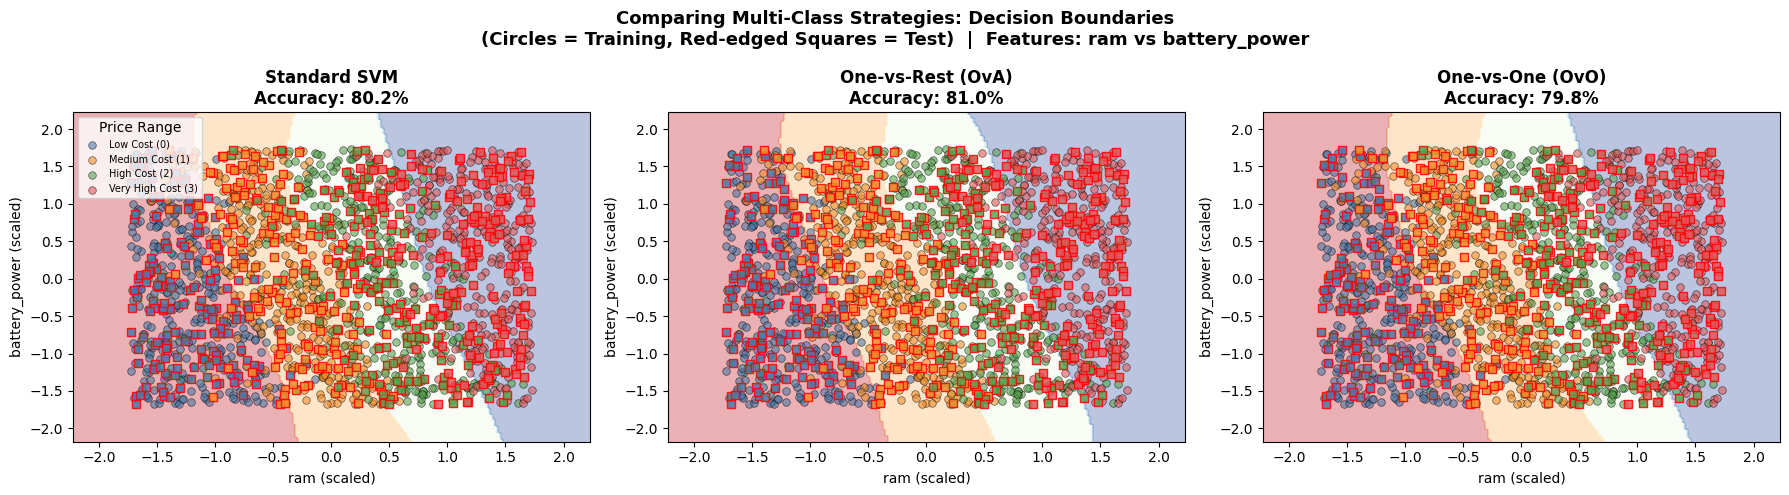

In [79]:
# RAM and battery_power are the two most discriminative features
FEAT_IDX = [13, 0]
FEAT_NAMES = [df.drop(columns=['price_range']).columns[i] for i in FEAT_IDX]

X_2d = X_scaled[:, FEAT_IDX]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

models_2d = {
    'Standard SVM'      : SVC(kernel='rbf', gamma='scale', C=1.0),
    'One-vs-Rest (OvA)' : OneVsRestClassifier(SVC(kernel='rbf', gamma='scale', C=1.0)),
    'One-vs-One (OvO)'  : OneVsOneClassifier(SVC(kernel='rbf', gamma='scale', C=1.0))
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

COLORS = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

for idx, (name, model) in enumerate(models_2d.items()):
    model.fit(X_train_2d, y_train_2d)
    y_pred_2d = model.predict(X_test_2d)
    acc_2d = accuracy_score(y_test_2d, y_pred_2d)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, alpha=0.35, cmap='RdYlBu')

    for cls, color in zip([0, 1, 2, 3], COLORS):
        mask = y_train_2d == cls
        axes[idx].scatter(
            X_train_2d[mask, 0], X_train_2d[mask, 1],
            c=color, edgecolors='k', linewidths=0.5,
            s=30, alpha=0.6, marker='o',
            label=CLASS_NAMES[cls] if idx == 0 else ''
        )

    for cls, color in zip([0, 1, 2, 3], COLORS):
        mask = y_test_2d == cls
        axes[idx].scatter(
            X_test_2d[mask, 0], X_test_2d[mask, 1],
            c=color, edgecolors='red', linewidths=1.0,
            s=40, alpha=0.85, marker='s'
        )

    axes[idx].set_xlabel(FEAT_NAMES[0] + ' (scaled)', fontsize=10)
    axes[idx].set_ylabel(FEAT_NAMES[1] + ' (scaled)', fontsize=10)
    axes[idx].set_title(f'{name}\nAccuracy: {acc_2d*100:.1f}%',
                        fontsize=12, fontweight='bold')

axes[0].legend(loc='upper left', fontsize=7, title='Price Range')
plt.suptitle(
    'Comparing Multi-Class Strategies: Decision Boundaries\n'
    '(Circles = Training, Red-edged Squares = Test)  |  '
    f'Features: {FEAT_NAMES[0]} vs {FEAT_NAMES[1]}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [80]:
print("\n Cross-Validation Scores (5-Fold)")
print("This tests the model 5 times on different splits of data to confirm")
print("the accuracy is consistent and not just a lucky result.\n")

for name, model in [("Standard SVM", model_standard),
                     ("One-vs-Rest (OvA)", model_ovr),
                     ("One-vs-One (OvO)", model_ovo)]:
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"  {name}")
    print(f"    Scores per fold : {[f'{s*100:.2f}%' for s in scores]}")
    print(f"    Mean Accuracy   : {scores.mean()*100:.2f}%")
    print(f"    Std Deviation   : ±{scores.std()*100:.2f}%")
    print(f"    → A low std deviation means the model is stable and reliable.\n")


 Cross-Validation Scores (5-Fold)
This tests the model 5 times on different splits of data to confirm
the accuracy is consistent and not just a lucky result.

  Standard SVM
    Scores per fold : ['90.25%', '85.75%', '91.25%', '87.00%', '88.25%']
    Mean Accuracy   : 88.50%
    Std Deviation   : ±2.02%
    → A low std deviation means the model is stable and reliable.

  One-vs-Rest (OvA)
    Scores per fold : ['71.25%', '71.25%', '72.50%', '69.25%', '71.00%']
    Mean Accuracy   : 71.05%
    Std Deviation   : ±1.04%
    → A low std deviation means the model is stable and reliable.

  One-vs-One (OvO)
    Scores per fold : ['90.00%', '85.75%', '91.25%', '87.00%', '88.25%']
    Mean Accuracy   : 88.45%
    Std Deviation   : ±1.98%
    → A low std deviation means the model is stable and reliable.



In [81]:
# New entry data
print("\n" + "=" * 70)
print("NEW DATA ENTRY (USER INPUT)")
print("=" * 70)

print("Enter the following mobile phone features:")

battery_power = float(input("Battery Power: "))
blue = int(input("Bluetooth (0/1): "))
clock_speed = float(input("Clock Speed: "))
dual_sim = int(input("Dual SIM (0/1): "))
fc = int(input("Front Camera: "))
four_g = int(input("4G (0/1): "))
int_memory = int(input("Internal Memory: "))
m_dep = float(input("Mobile Depth: "))
mobile_wt = int(input("Mobile Weight: "))
n_cores = int(input("Number of Cores: "))
pc = int(input("Primary Camera: "))
px_height = int(input("Pixel Height: "))
px_width = int(input("Pixel Width: "))
ram = int(input("RAM: "))
sc_h = int(input("Screen Height: "))
sc_w = int(input("Screen Width: "))
talk_time = int(input("Talk Time: "))
three_g = int(input("3G (0/1): "))
touch_screen = int(input("Touch Screen (0/1): "))
wifi = int(input("WiFi (0/1): "))

new_data = [[
    battery_power, blue, clock_speed, dual_sim, fc, four_g,
    int_memory, m_dep, mobile_wt, n_cores, pc, px_height,
    px_width, ram, sc_h, sc_w, talk_time, three_g,
    touch_screen, wifi
]]

prediction = model_ovo.predict(new_data)

print("\nPredicted price range:", prediction[0])


NEW DATA ENTRY (USER INPUT)
Enter the following mobile phone features:
Battery Power: 500
Bluetooth (0/1): 0
Clock Speed: 23
Dual SIM (0/1): 1
Front Camera: 3
4G (0/1): 1
Internal Memory: 23
Mobile Depth: 12
Mobile Weight: 54
Number of Cores: 8
Primary Camera: 2
Pixel Height: 45
Pixel Width: 13
RAM: 56
Screen Height: 12
Screen Width: 54
Talk Time: 12
3G (0/1): 1
Touch Screen (0/1): 1
WiFi (0/1): 1

Predicted price range: 0


# Summary:

We were given a dataset of 2,000 mobile phones, each described by 20 technical features such as RAM, battery power, camera quality, screen size, and more. Each phone is labeled with one of four price ranges: Low Cost = 0, Medium Cost = 1, High Cost = 2, and Very High Cost  = 3.

For One-vs-Rest (OvA), we ask for each price range: "Is this phone in THIS price range, or not?" So we train four separate classifiers, one asking if it's Low Cost, one for Medium Cost, one for High Cost, and one for Very High Cost. The phone gets assigned to whichever category the model is most confident about. For One-vs-One (OvO), we instead compare every possible pair of price ranges against each other, giving us six mini-classifiers: Low vs Medium, Low vs High, Low vs Very High, Medium vs High, Medium vs Very High, and High vs Very High. Each one votes, and the price range with the most votes wins.

After running all three strategies on all 20 features, all three performed exceptionally well above 96% accuracy. This tells us that the 20 features in this dataset are genuinely strong predictors of price range. OvO matched the Standard SVM because scikit-learn's default SVM already uses OvO internally, so they are essentially doing the same thing. OvA came in slightly lower, which is typical, because OvA trains each classifier on an uneven fight of 1 class versus 3 combined classes, it has a harder job and can be slightly less precise. The small difference of around 0.7% between OvA and OvO is not dramatic though, and both strategies are strong performers on this dataset.

SVMs are powerful classifiers but need strategies like OvA or OvO to handle more than two categories. On this dataset, both strategies work extremely well because the features are clean, balanced, and highly informative. OvO tends to be slightly more accurate on small, balanced datasets like this one but takes longer to train as the number of classes grows. OvA on the other hand is faster and scales better when you have many categories of ten or more.

